In [ ]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = last 4 digits of your Drexel ID. 

import numpy as np

seed = 4898  # replace with the last 4 digits of your Drexel ID if desired
rng = np.random.default_rng(seed)

n_readings = 200
timestamps = rng.uniform(0, 10, size=n_readings)

sensor_a = rng.normal(loc=25.0, scale=3.0, size=n_readings)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n_readings)

assert sensor_a.shape == (n_readings,), f"sensor_a.shape is {sensor_a.shape}, expected {(n_readings,)}"
assert sensor_b.shape == (n_readings,), f"sensor_b.shape is {sensor_b.shape}, expected {(n_readings,)}"

# Sort timestamps for a time-series ordering, keeping readings aligned.
order = np.argsort(timestamps)
timestamps = timestamps[order]
sensor_a = sensor_a[order]
sensor_b = sensor_b[order]


timestamps, sensor_a, sensor_b

(array([0.05365965, 0.15645962, 0.22832851, 0.28356848, 0.3366392 ,
        0.33798144, 0.34405831, 0.41629753, 0.41703603, 0.45436539,
        0.49930065, 0.52104831, 0.54157115, 0.65363811, 0.85259332,
        0.95661893, 1.02590468, 1.09460301, 1.09498676, 1.23510996,
        1.24282267, 1.27870913, 1.29301656, 1.30685343, 1.39837915,
        1.58066722, 1.63945336, 1.87030753, 1.87777989, 1.88524387,
        1.91773494, 1.9272229 , 2.01028769, 2.01455482, 2.0225734 ,
        2.03860489, 2.05493955, 2.09041569, 2.09236809, 2.13359402,
        2.13519113, 2.20795296, 2.29162123, 2.35410564, 2.35491721,
        2.41538206, 2.45110991, 2.48215084, 2.60333984, 2.69084654,
        2.76025581, 2.79327993, 2.80575258, 2.98850681, 3.0077598 ,
        3.01498656, 3.02583281, 3.03290229, 3.12794666, 3.17299819,
        3.17471858, 3.26507537, 3.33084431, 3.36978215, 3.37638542,
        3.38004124, 3.39365768, 3.41274901, 3.50044177, 3.52401887,
        3.54526684, 3.5554459 , 3.63717512, 3.66

- Used `np.random.default_rng(seed)` for reproducible random data.
- Generated 200 timestamps uniformly from 0 to 10 seconds.
- Created sensor readings with the requested means and standard deviations.
- Sorted timestamps to make the dataset behave like a time series while preserving aligned readings.

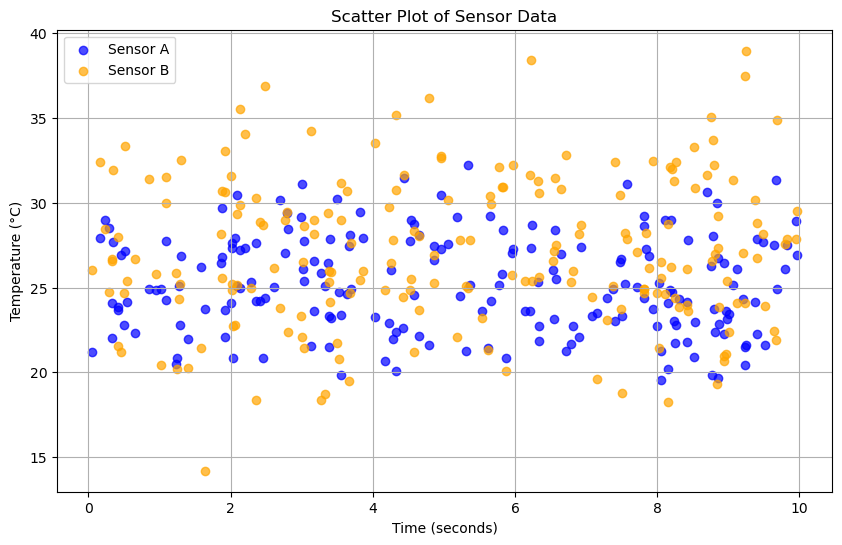

In [ ]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(timestamps, sensor_a, color='blue', label='Sensor A', alpha=0.7)
plt.scatter(timestamps, sensor_b, color='orange', label='Sensor B', alpha=0.7)
plt.xlabel('Time (seconds)')
plt.ylabel('Temperature (°C)')
plt.title('Scatter Plot of Sensor Data')
plt.legend()
plt.grid(True)
plt.show()

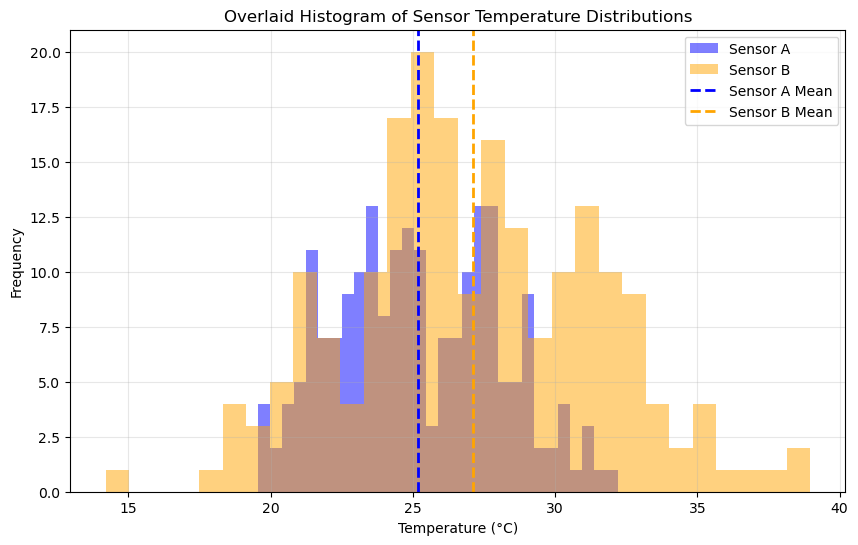

In [ ]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.hist(sensor_a, bins=30, alpha=0.5, label='Sensor A', color='blue')
plt.hist(sensor_b, bins=30, alpha=0.5, label='Sensor B', color='orange')
plt.axvline(np.mean(sensor_a), color='blue', linestyle='--', linewidth=2, label='Sensor A Mean')
plt.axvline(np.mean(sensor_b), color='orange', linestyle='--', linewidth=2, label='Sensor B Mean')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Overlaid Histogram of Sensor Temperature Distributions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/1w/wt716nts7lb4dd_7j6l7wxv40000gn/T/ipykernel_2624/3613979973.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sensor_a, sensor_b], labels=['Sensor A', 'Sensor B'])


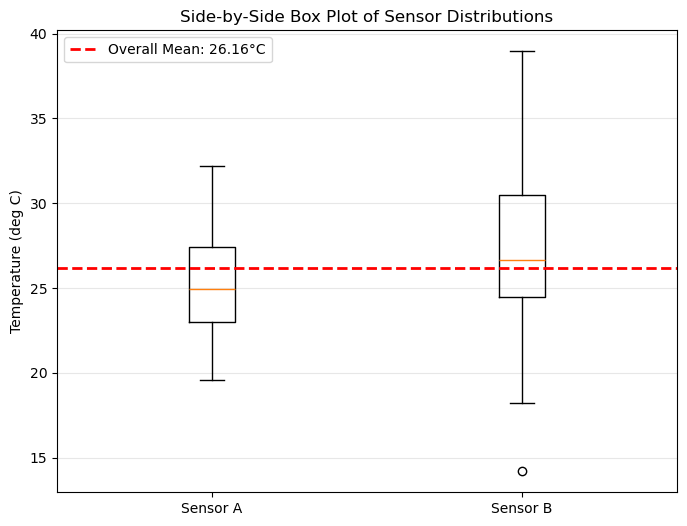

In [9]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
plt.boxplot([sensor_a, sensor_b], labels=['Sensor A', 'Sensor B'])
overall_mean = np.mean(np.concatenate([sensor_a, sensor_b]))
plt.axhline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}°C')
plt.ylabel('Temperature (deg C)')
plt.title('Side-by-Side Box Plot of Sensor Distributions')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()